# Phase 2: XGBoost Explainability with SHAP

This notebook explains the tuned Phase 1 XGBoost credit risk model. It uses a bounded test-set sample to respect the 8 GB RAM constraint and saves reusable SHAP plots for later reporting/UI work.

In [2]:
import shap
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import sys
import os

shap.initjs()

# Import our predictor to handle feature alignment safely
sys.path.append(os.path.abspath('..'))
from src.risk_models.predict import RiskModelPredictor

RANDOM_STATE = 42
SHAP_SAMPLE_SIZE = 2000
SHAP_OUTPUT_DIR = Path('../artifacts/shap_plots')
SHAP_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

## 1. Load Model and Data Sample

In [3]:
# Load the tuned XGBoost model through the production wrapper
predictor = RiskModelPredictor(
    model_path='../models/xgboost_baseline.joblib',
    metadata_path='../data/processed/features/lendingclub_baseline_metadata.json'
)

# Load the saved test set from notebook 03
df_test = pd.read_parquet('../data/processed/features/X_test_baseline.parquet')

# Use only the exact columns expected by the trained model
missing_features = [col for col in predictor.expected_features if col not in df_test.columns]
if missing_features:
    raise ValueError(f"X_test is missing model features: {missing_features[:10]}")

X_test_aligned = df_test[predictor.expected_features]

# Bound the SHAP workload for the 8 GB RAM constraint
sample_size = min(SHAP_SAMPLE_SIZE, len(X_test_aligned))
X_sample = X_test_aligned.sample(n=sample_size, random_state=RANDOM_STATE)

print(f"Loaded test set: {X_test_aligned.shape[0]} rows, {X_test_aligned.shape[1]} features.")
print(f"Using SHAP sample: {X_sample.shape[0]} rows.")

Loaded test set: 58675 rows, 123 features.
Using SHAP sample: 2000 rows.


## 2. Calculate SHAP Values

In [4]:
explainer = shap.TreeExplainer(predictor.model)
shap_values = explainer(X_sample)

print(f"SHAP values calculated: {shap_values.values.shape}")

SHAP values calculated: (2000, 123)


## 3. Global Summary Plot (Beeswarm)

This plot shows the most important features across the sampled test loans. Red indicates high feature values, blue indicates low feature values, rightward movement pushes toward default risk, and leftward movement pushes toward repayment.

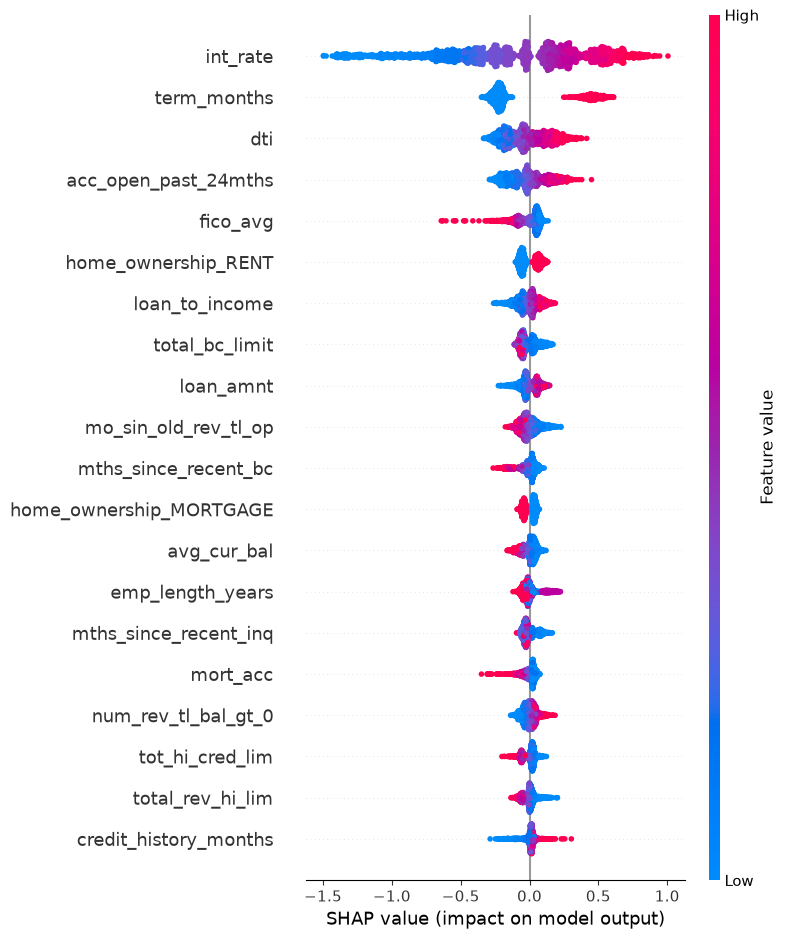

Saved SHAP summary plot to: ..\artifacts\shap_plots\global_summary_beeswarm.png


In [5]:
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_sample, show=False, max_display=20)
summary_path = SHAP_OUTPUT_DIR / 'global_summary_beeswarm.png'
plt.savefig(summary_path, bbox_inches='tight', dpi=150)
plt.show()
plt.close()

print(f"Saved SHAP summary plot to: {summary_path}")

## 4. SHAP Feature Importance (Bar Plot)
A simpler view showing the average impact of each feature on model output magnitude.

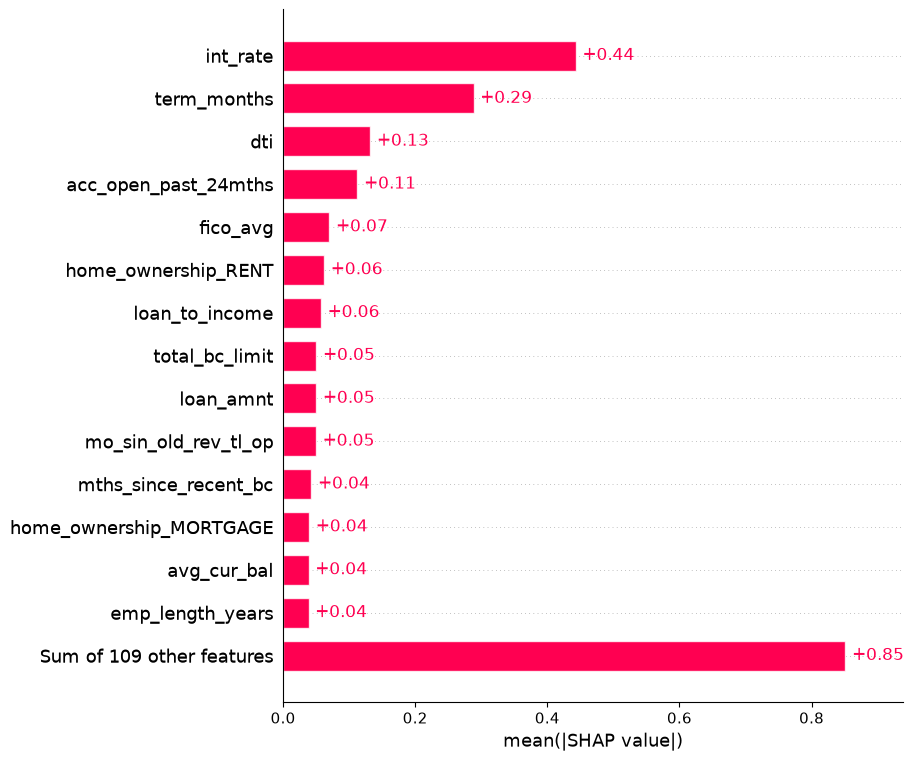

Saved SHAP feature importance plot to: ..\artifacts\shap_plots\global_feature_importance_bar.png


In [6]:
plt.figure(figsize=(10, 8))
shap.plots.bar(shap_values, max_display=15, show=False)
bar_path = SHAP_OUTPUT_DIR / 'global_feature_importance_bar.png'
plt.savefig(bar_path, bbox_inches='tight', dpi=150)
plt.show()
plt.close()

print(f"Saved SHAP feature importance plot to: {bar_path}")

## 5. Dependence Plots
Let's look at how specific features interact with risk. For example, how does `int_rate` (Interest Rate) affect the probability of default?

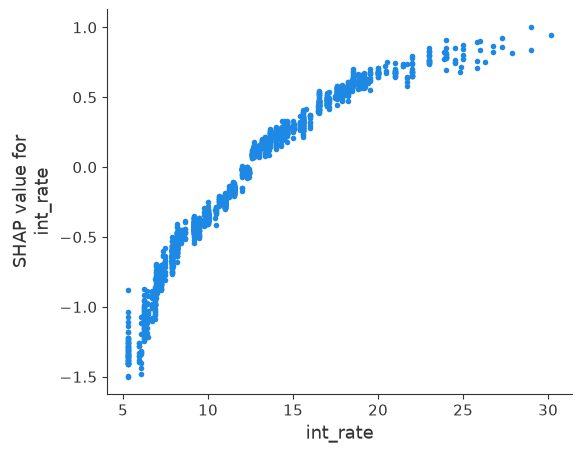

Saved SHAP dependence plot for int_rate to: ..\artifacts\shap_plots\dependence_int_rate.png


In [7]:
# Use int_rate when available; otherwise use the strongest global feature
if 'int_rate' in X_sample.columns:
    dependence_feature = 'int_rate'
else:
    mean_abs_shap = np.abs(shap_values.values).mean(axis=0)
    dependence_feature = X_sample.columns[np.argmax(mean_abs_shap)]

shap.dependence_plot(
    dependence_feature,
    shap_values.values,
    X_sample,
    interaction_index=None,
    show=False
)
dependence_path = SHAP_OUTPUT_DIR / f'dependence_{dependence_feature}.png'
plt.savefig(dependence_path, bbox_inches='tight', dpi=150)
plt.show()
plt.close()

print(f"Saved SHAP dependence plot for {dependence_feature} to: {dependence_path}")

## 6. Phase 2 Handoff

Notebook 04 now provides memory-safe global SHAP analysis for the tuned XGBoost model. The saved plots in `artifacts/shap_plots/` can support later explainability pages and underwriter reports, while local per-loan explanations stay in `src/explainability/shap_utils.py`.